In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import f1_score 
import matplotlib.pyplot as plt
import seaborn as sns

from knn import KNNClassifier
np.random.seed(42)  #fixing the random action, so when we run is always the same result

In [12]:
def preprocess(df):
    target_col = df.columns[-1]     #assuming last col as target
    X = df.drop(columns=[target_col]).copy()    #all features
    y_raw =df[target_col].copy()    #list of target
    #find the unique lables and turn them into numbers
    unic_classes, y = np.unique(y_raw, return_inverse=True)
    #convert characteristical values to nº(one-hot encoding)
    cat_cols = X.select_dtypes(include=['object','category','string']).columns
    if len(cat_cols) > 0: X = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    #for all nº cols, change missing values to the mean, so it wont change a lot
    num_cols = X.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        if X[col].isna().all(): X[col] = 0
        else: X[col] = X[col].fillna(X[col].median())
    X = X.values.astype(float)  #convrting pandas df into np array

    mean = X.mean(axis=0)
    sd = X.std(axis=0)  #standard deviation
    sd[sd==0] = 1   #column with constant values =0, avoid division by zero replace by 1
    X = (X-mean)/sd #normalization, Z~(0,1)

    return X, y, unic_classes, target_col

In [13]:
FOLDER = './multiclass_classification'   #directory

res = []
for f in os.listdir(FOLDER):
    path = os.path.join(FOLDER, f)
    df = pd.read_csv(path)
    X, y, classes, targets = preprocess(df)
    #80/20 split train and test
    idx = np.random.permutation(len(X)) #random the indice
    train_size = int(0.8*len(X))
    X_train = X[idx[:train_size]]
    X_test = X[idx[train_size:]]
    y_train = y[idx[:train_size]]
    y_test = y[idx[train_size:]]
    #knn base code (MLAgoritms, rushter)
    knn = KNNClassifier(k=5)
    #setting attributes correctly according to the algorithm
    knn.X = np.nan_to_num(X_train)
    knn.y = y_train
    #prediction from knn
    y_pred = knn._predict(X_test)
    #creates a true/false list to calculate the accuracy 0 to 1
    acc = np.mean(y_pred == y_test)
    #macro f1, a balanced f1(balance between precision and recall)
    macro_f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    res.append({
        'Dataset':f,
        'Samples':len(df),
        'Features':X.shape[1],
        'Classes': len(classes),
        'Accuracy': round(acc, 4),
        'Macro_F1': round(macro_f1, 4),
        'Target': targets})
res_df = pd.DataFrame(res).sort_values('Accuracy')
display(res_df)
res_df.to_csv('result.csv',index=False)

,Dataset,Samples,Features,Classes,Accuracy,Macro_F1,Target
32,dataset_382_ipums_la_97-small.csv,7019,652,8,0.3006,0.2186,movedin
23,dataset_338_grub-damage.csv,155,29,4,0.3871,0.3815,GG_new
44,dataset_9_autos.csv,205,65,6,0.4146,0.2939,symboling
15,dataset_285_flags.csv,194,45,8,0.4872,0.3744,religion
26,dataset_373_UNIX_user_data.csv,9100,5964,9,0.4923,0.4239,user
14,dataset_23_cmc.csv,1473,9,3,0.5017,0.4708,Contraceptive_method_used
37,dataset_48_tae.csv,151,5,3,0.5161,0.5018,Class_attribute
10,dataset_188_eucalyptus.csv,736,86,5,0.5338,0.5001,Utility
40,dataset_5_arrhythmia.csv,452,279,13,0.5714,0.2047,class
5,dataset_181_yeast.csv,1484,8,10,0.5993,0.5569,class_protein_localization


/tmp/ipykernel_26496/749950545.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=res_df, x='Dataset',y='Accuracy', palette='viridis')


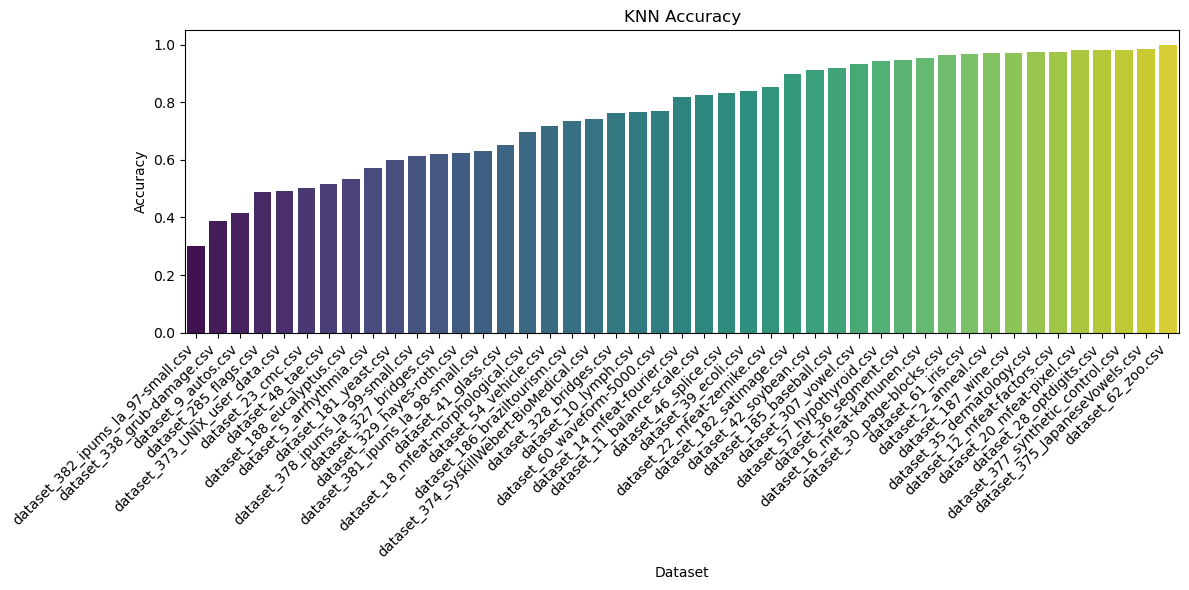

In [17]:
plt.figure(figsize=(12,6))
sns.barplot(data=res_df, x='Dataset',y='Accuracy', palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('KNN Accuracy')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()